In [1]:
from experiments_vllm import *
from data import *
from config_subject_skew import *

In [2]:
# Environment fixes
import os
os.environ["FLASHINFER_DISABLE_VERSION_CHECK"] = "1"

In [3]:
# Set seeds
seed = 43
torch.manual_seed(seed);

In [4]:
# Get data: generalize prompts and per-subject
print(subjects)
dataset_general = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed)
datasets_subjects = [get_data_mmlu(n_samples=n_samples, shuffle_seed=seed, subset=s) for s in subjects]
prompts_general = format_prompts_mmlu(dataset_general)
prompts_subjects = [format_prompts_mmlu(d) for d in datasets_subjects]

['abstract_algebra']
Streaming cais/mmlu (all) (samples: 10)...
Streaming cais/mmlu (abstract_algebra) (samples: 10)...


In [5]:
# Get model
model, tokenizer = load_model(model_id, max_memory=max_memory, enable_bnb=True)
probe = MoEProbeQwen(model)

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 24 router layers.
MoEHook: Model has 24 routers each with 60 experts and selects k=4 at each layer.
MoEProbe: Qwen1.5-MoE-A2.7B model also has shared expert with intermediate size: 5632 (Equivalent to ~4 routed experts)


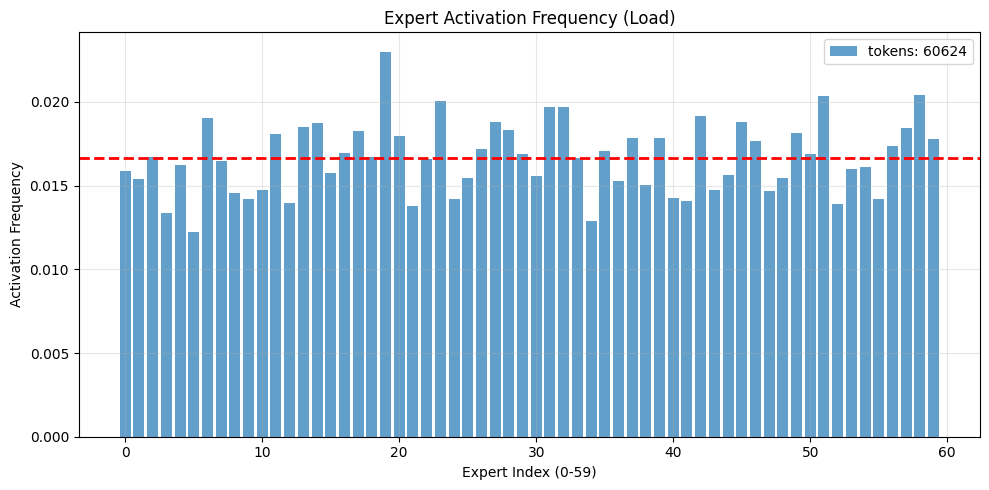

In [6]:
# Run some general prompts
for prompt in prompts_general:
    response, probs, active_experts = single_generate(model, tokenizer, probe=probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

['abstract_algebra']


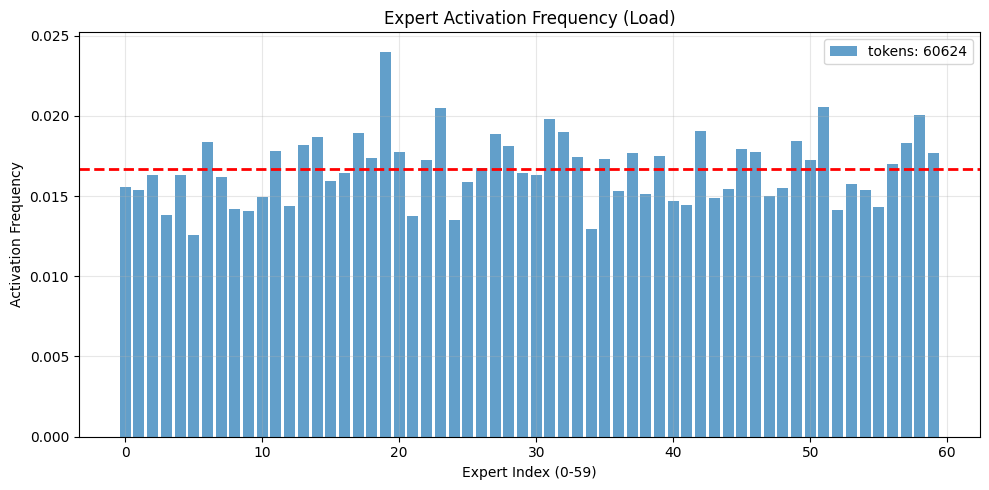

In [8]:
# Run some subject prompts
probe.clear()
for prompt in prompts_subjects[0]:
    response, probs, active_experts = single_generate(model, tokenizer, probe=probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

In [ ]:
# Make trace directories
if not os.path.isdir(trace_path_general):
    os.mkdir(trace_path_general)
for p in trace_paths_subjects:
    if not os.path.isdir(p):
        os.mkdir(p)

In [ ]:
# Run experiment over generalized MMLU questions
overall_results = await run_experiment_vllm_throughput(model_id,
                                                       prompts_general,
                                                       seed=seed,
                                                       max_new_tokens=max_new_tokens,
                                                       max_model_len=max_model_len,
                                                       batch_size=batch_size,
                                                       concurrency_limit=batch_size*4,
                                                       gpu_memory_utilization=gpu_memory_utilization,
                                                       n_gpus=n_gpus,
                                                       n_warmup_samples=n_warmup_samples,
                                                       print_output=False,
                                                       enable_expert_parallel=enable_expert_parallel,
                                                       enable_prefix_caching=enable_prefix_caching,
                                                       trace_dir=None)

In [ ]:
# Run experiment over single MMLU subject
subject_results = await run_experiment_vllm_throughput(model_id,
                                                       prompts_subjects[0],
                                                       seed=seed,
                                                       max_new_tokens=max_new_tokens,
                                                       max_model_len=max_model_len,
                                                       batch_size=batch_size,
                                                       concurrency_limit=batch_size*4,
                                                       gpu_memory_utilization=gpu_memory_utilization,
                                                       n_gpus=n_gpus,
                                                       n_warmup_samples=n_warmup_samples,
                                                       print_output=False,
                                                       enable_expert_parallel=enable_expert_parallel,
                                                       enable_prefix_caching=enable_prefix_caching,
                                                       trace_dir=None)

In [ ]:
# Save results
#import pickle
#with open(results_file_balanced, 'wb') as file:
#    pickle.dump(balanced_results, file)
#with open(results_file_imbalanced, 'wb') as file:
#    pickle.dump(imbalanced_results, file)